# 1. 最大流问题
### 3. 用 networkx 求网络最大流

最大流流量: 5
最大流分布: {1: {2: 2, 3: 3}, 2: {4: 2}, 3: {2: 0, 5: 3}, 4: {3: 0, 5: 0, 6: 2}, 5: {6: 3}, 6: {}}
邻接矩阵
 [[0 2 3 0 0 0]
 [0 0 0 2 0 0]
 [0 0 0 0 3 0]
 [0 0 0 0 0 2]
 [0 0 0 0 0 3]
 [0 0 0 0 0 0]]


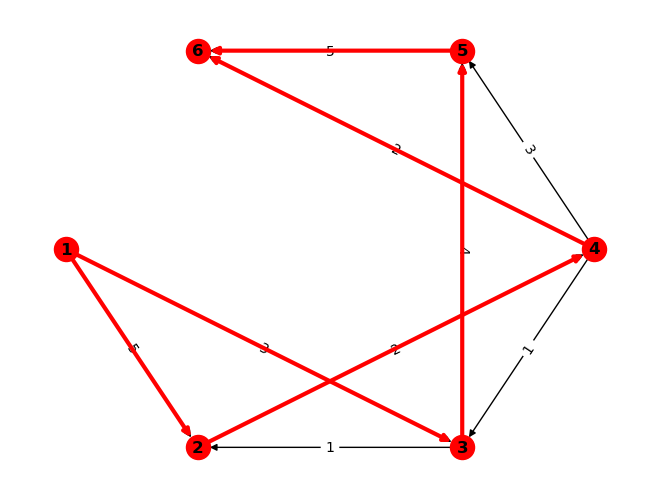

In [ ]:
# 点号从0开始
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# 原始边列表（start, target, capacity）
edges = [(1, 2, 5), (1, 3, 3), (2, 4, 2), (3, 2, 1), (3, 5, 4),
         (4, 3, 1), (4, 5, 3), (4, 6, 2), (5, 6, 5)]

G = nx.DiGraph()
for u, v, cap in edges:
    G.add_edge(u, v, capacity=cap)  # 点从1开始

# 计算最大流（源=1，汇=6）
flow_value, flow_dict = nx.maximum_flow(G, 1, 6)

print("最大流流量:", flow_value)
# 一条从 1→2→4→6 的 2 单位流，和一条从 1→3→5→6 的 3 单位流，总共 5 单位
print("最大流分布:", flow_dict)

# 把结果转成邻接矩阵（节点编号 1…6 → 行列 0…5）
n = max(G.nodes)
adj = np.zeros((n, n), dtype=int)
for i in flow_dict:
    for j, w in flow_dict[i].items():
        adj[i-1, j-1] = w          # 行/列减 1 只是为了矩阵下标从 0 开始
print("邻接矩阵\n", adj)

# 画图
pos = nx.shell_layout(G)
cap_labels = nx.get_edge_attributes(G, 'capacity')
nx.draw(G, pos, with_labels=True, node_color='r', font_weight='bold')
nx.draw_networkx_edge_labels(G, pos, edge_labels=cap_labels)

# 把流值>0 的边染成红色粗线
flow_edges = [(i, j) for i in flow_dict for j, w in flow_dict[i].items() if w > 0]
nx.draw_networkx_edges(G, pos, edgelist=flow_edges, edge_color='r', width=3)

plt.show()

最大流的流量为: 5
最大流为: {0: {1: 2, 2: 3}, 1: {3: 2}, 2: {1: 0, 4: 3}, 3: {2: 0, 4: 0, 5: 2}, 4: {5: 3}, 5: {}}
最大流的邻接矩阵为:
[[0 2 3 0 0 0]
 [0 0 0 2 0 0]
 [0 0 0 0 3 0]
 [0 0 0 0 0 2]
 [0 0 0 0 0 3]
 [0 0 0 0 0 0]]
[(0, 1), (0, 2), (1, 3), (2, 4), (3, 5), (4, 5)]


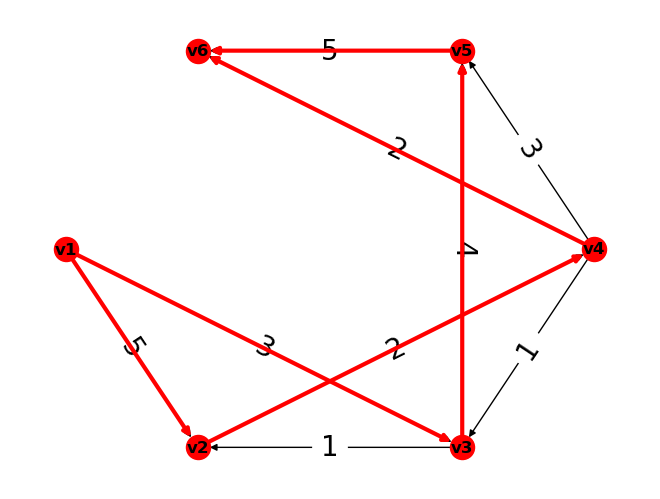

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

L = [(1, 2, 5), (1, 3, 3), (2, 4, 2), (3, 2, 1), (3, 5, 4),
     (4, 3, 1), (4, 5, 3), (4, 6, 2), (5, 6, 5)]  # (start, target, capacity)
G = nx.DiGraph()
for k in range(len(L)):
    G.add_edge(L[k][0] - 1, L[k][1] - 1, capacity=L[k][2])
# 点从0开始(networkx不做特殊要求)，更方便配合数组、邻接矩阵的行列对齐

value, flow_dict = nx.maximum_flow(G, 0, 5)

print(f"最大流的流量为: {value}")
# 一条从 1→2→4→6 的 2 单位流，和一条从 1→3→5→6 的 3 单位流，总共 5 单位
print(f"最大流为: {flow_dict}")

n = len(flow_dict)  # n=6
adj_mat = np.zeros((n, n), dtype=int)  # adj_mat--adjacency_matrix邻接矩阵,dtype=float(default)
for i, adj in flow_dict.items():  # dict.items()取出键值对，返回可迭代对象,其中,i=key(起点), adj=value(可到达的终点及流量)
    for j, weight in adj.items():  # 内层字典, j=key(每条边的终点), weight=value(该边的流量)
        adj_mat[i, j] = weight  # i, j索引从0开始，与上面的循环点从0开始对应(不从0开始i,j减一),邻接矩阵加入对应边的流量
print(f"最大流的邻接矩阵为:\n{adj_mat}")

ni, nj = np.nonzero(adj_mat)  # 非零弧的两端顶点编号,返回元组(非0元素行索引, 非0元素列索引)
key = range(n)  # 键:0, 1, 2, 3, 4, 5
s = ['v' + str(i+1) for i in range(n)]  # 值:v1, v2, v3, v4, v5, v6(str类型)
s = dict(zip(key, s))  # 构造用于顶点标注的字符字典,zip(iterable1, iterable2, ...)组合成元组(zip对象，需转换才能输出)

plt.rcParams['font.size'] = 16
pos = nx.shell_layout(G)  # 顶点在同心圆上
w = nx.get_edge_attributes(G, 'capacity')  # fanhui{(start, target): 流量, ...}
nx.draw(G, pos, font_weight='bold', labels=s, node_color='r')
nx.draw_networkx_edge_labels(G, pos, font_size=20, edge_labels=w)
path_edges = list(zip(ni, nj))  # [(0, 1), (0, 2), (1, 3), (2, 4), (3, 5), (4, 5)]要画的边
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='r', width=3)
plt.show()  

In [19]:
import numpy as np
import networkx as nx

L = [(1, 2, 5, 3), (1, 3, 3, 6), (2, 4, 2, 8), (3, 2, 1, 2), (3, 5, 4, 2),
     (4, 3, 1, 1), (4, 5, 3, 4), (4, 6, 2, 10), (5, 6, 5, 2)]  # (start, target, capacity, weight)
G = nx.DiGraph()

for k in range(len(L)):
    G.add_edge(L[k][0] - 1, L[k][1] -1, capacity=L[k][2], weight=L[k][3])

mincostFlow = nx.max_flow_min_cost(G, 0, 5)

print(f"所求流为:\n{mincostFlow}")

mincost = nx.cost_of_flow(G, mincostFlow)

print(f"最小费用为: {mincost}")

flow_mat = np.zeros((6, 6), dtype=int)
for i, adj in mincostFlow.items():
    for j, f in adj.items():
        flow_mat[i, j] = f
        
print(f"最小费用最大流的邻集矩阵为:\n{flow_mat}")

所求流为:
{0: {1: 2, 2: 3}, 1: {3: 2}, 2: {1: 0, 4: 4}, 3: {2: 1, 4: 1, 5: 0}, 4: {5: 5}, 5: {}}
最小费用为: 63
最小费用最大流的邻集矩阵为:
[[0 2 3 0 0 0]
 [0 0 0 2 0 0]
 [0 0 0 0 4 0]
 [0 0 1 0 1 0]
 [0 0 0 0 0 5]
 [0 0 0 0 0 0]]
